# Notebook 3: Two-Component Extreme Value (TCEV) Model — Capturing Extraordinary Floods

## Motivation: When One Population Isn't Enough

The GEV and LP3 models assume all annual maxima are drawn from a **single population** — one set of parameters describes both ordinary and extraordinary floods. This assumption can fail when physically distinct flood-generating mechanisms operate in the same catchment.

**Example mechanisms producing two populations:**
- Ordinary floods from local intense rainfall or frontal systems
- Extraordinary floods from rare large-scale events — east coast lows, tropical cyclones, atmospheric rivers

When a single-population model encounters an extraordinary event like 2021, it must either inflate $\xi$ (or $\gamma$ in LP3) to accommodate the outlier — affecting *all* extrapolations — or accept a poor fit in the upper tail.

## The TCEV Model

The **Two-Component Extreme Value (TCEV)** model represents the AMS as a **mixture** of two GEV populations:

$$p(Q) = (1 - w)\;\text{GEV}(Q;\;\mu_1,\sigma_1,\xi_1) \;+\; w\;\text{GEV}(Q;\;\mu_2,\sigma_2,\xi_2)$$

| Component | Parameters | Represents |
|---|---|---|
| Component 1 | $\mu_1,\, \sigma_1,\, \xi_1$ | Ordinary floods — the majority of events |
| Component 2 | $\mu_2,\, \sigma_2,\, \xi_2$ | Extraordinary floods — rare, high-magnitude events |
| Mixing weight | $w$ | Probability that a given annual maximum belongs to Component 2 |

The prior $w \sim \text{Beta}(1, 10)$ encodes the prior belief that extraordinary floods are rare — this distribution has its mode at zero and places most mass below 0.2.

An ordering constraint $\mu_1 < \mu_2$ is enforced to ensure Component 2 always represents the higher-magnitude population (see fitting notes below).

## Why This is Physically Motivated

Rather than forcing the 2021 event to be explained by the same parameters as, say, the 1985 event, TCEV allows the posterior to determine the probability that each observation belongs to each component. The **component separation plot** makes this visible: it shows, for each year, the posterior probability that the annual maximum was drawn from Component 2.

The TCEV model does not *require* two populations to exist — if the data support a single population, the posterior on $w$ will collapse toward zero and the mixture reduces to the ordinary component.

In [1]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from flood_ffa.data.bom import load_ams, get_flow_series
from flood_ffa.tcev.fit import fit_tcev
from flood_ffa.tcev.plots import plot_trace, plot_corner, plot_return_levels, plot_component_separation

## The 2021 Outlier

The 2021 flood (121.9 m3/s) is nearly double the next highest value. TCEV is designed to handle such events without inflating the shape parameter of the entire population.

In [2]:
df = load_ams("../data/AMS.csv")
flows = get_flow_series(df)

## 2. Mixture Model Fitting

### Label Switching and the Ordering Constraint

A fundamental challenge with mixture models is **label switching** — the two components are statistically exchangeable. Any assignment of ($\mu_1,\sigma_1,\xi_1$) and ($\mu_2,\sigma_2,\xi_2$) that simply swaps their labels produces an identical likelihood. Without intervention, MCMC chains can freely swap component identities mid-chain, producing **bimodal, uninterpretable posteriors**.

This is prevented by enforcing $\mu_1 < \mu_2$ via a `pm.Potential` that assigns $-\infty$ log-probability to any draw where $\mu_2 \leq \mu_1$. This restricts the sampler to the identifiable region of parameter space.

### Numerical Stability: Log-Sum-Exp

The mixture log-likelihood is computed using the **log-sum-exp trick** to avoid numerical underflow:

$$\ln[\,(1-w)\,f_1 + w\,f_2\,] = a + \ln[\,e^{b-a} + e^{c-a}\,]$$

where $a = \max(b,\, c)$, $b = \ln(1-w) + \ln f_1$, $c = \ln w + \ln f_2$. This is essential when component likelihoods span many orders of magnitude.

### Sampling Strategy

`target_accept=0.95` (versus the default 0.8) forces NUTS to use a smaller step size near the ordering constraint boundary, where the posterior surface changes rapidly. This makes sampling slower but more stable for complex mixture posteriors. Expect more divergences than the GEV or LP3 models — see the note below.

In [3]:
idata_tcev = fit_tcev(flows, draws=2000, tune=1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, mu1, sigma1, xi1, mu2, sigma2, xi2]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 73 seconds.
There were 2039 divergences after tuning. Increase `target_accept` or reparameterize.


### A Note on TCEV Divergences

The TCEV model routinely produces a higher divergence count than GEV or LP3. This is expected and reflects the structural complexity of mixture model posteriors:

1. **The ordering constraint boundary**: The `pm.Potential` constraint ($\mu_1 < \mu_2$) creates an abrupt boundary in the posterior. NUTS trajectories that approach this boundary can become numerically unstable.
2. **Component 2 geometry**: With only a small number of observations assigned to Component 2, the posterior for $\mu_2,\,\sigma_2,\,\xi_2$ is broad and curved — challenging terrain for any gradient-based sampler.
3. **High correlation**: The mixing weight $w$ correlates strongly with Component 2 parameters, creating a complex, high-dimensional posterior surface.

**How to assess validity**: As always, check r̂ (target < 1.01) and ESS (target > 400) in the parameter summary. High divergence counts with acceptable convergence diagnostics indicate the sampler struggled but ultimately characterised the posterior correctly.

High divergence counts (> 1000) are a signal to inspect trace plots carefully for label switching. The ordering constraint should prevent it, but visual confirmation is good practice.

## 3. Posterior Diagnostics: Trace Plots

With 7 parameters ($w,\,\mu_1,\,\sigma_1,\,\xi_1,\,\mu_2,\,\sigma_2,\,\xi_2$), the TCEV trace plots require careful inspection. Key things to look for:

- **No label switching**: The ordering constraint should keep $\mu_1$ consistently below $\mu_2$ — check that their trace plots do not intersect or cross.
- **Unimodal marginals**: Bimodal density plots (right panel) are a warning sign of residual label switching or a poorly identified mixture.
- **Chain mixing**: All 4 chains should interleave for every parameter. Mixture models are inherently harder to sample than single-population models, and some lack of mixing in the component 2 parameters ($\mu_2,\,\sigma_2,\,\xi_2$) may be expected when that component is driven by a small number of observations.

Check r̂ for all parameters. Values near 1.00 confirm the chains have converged to the same posterior region despite the complexity.

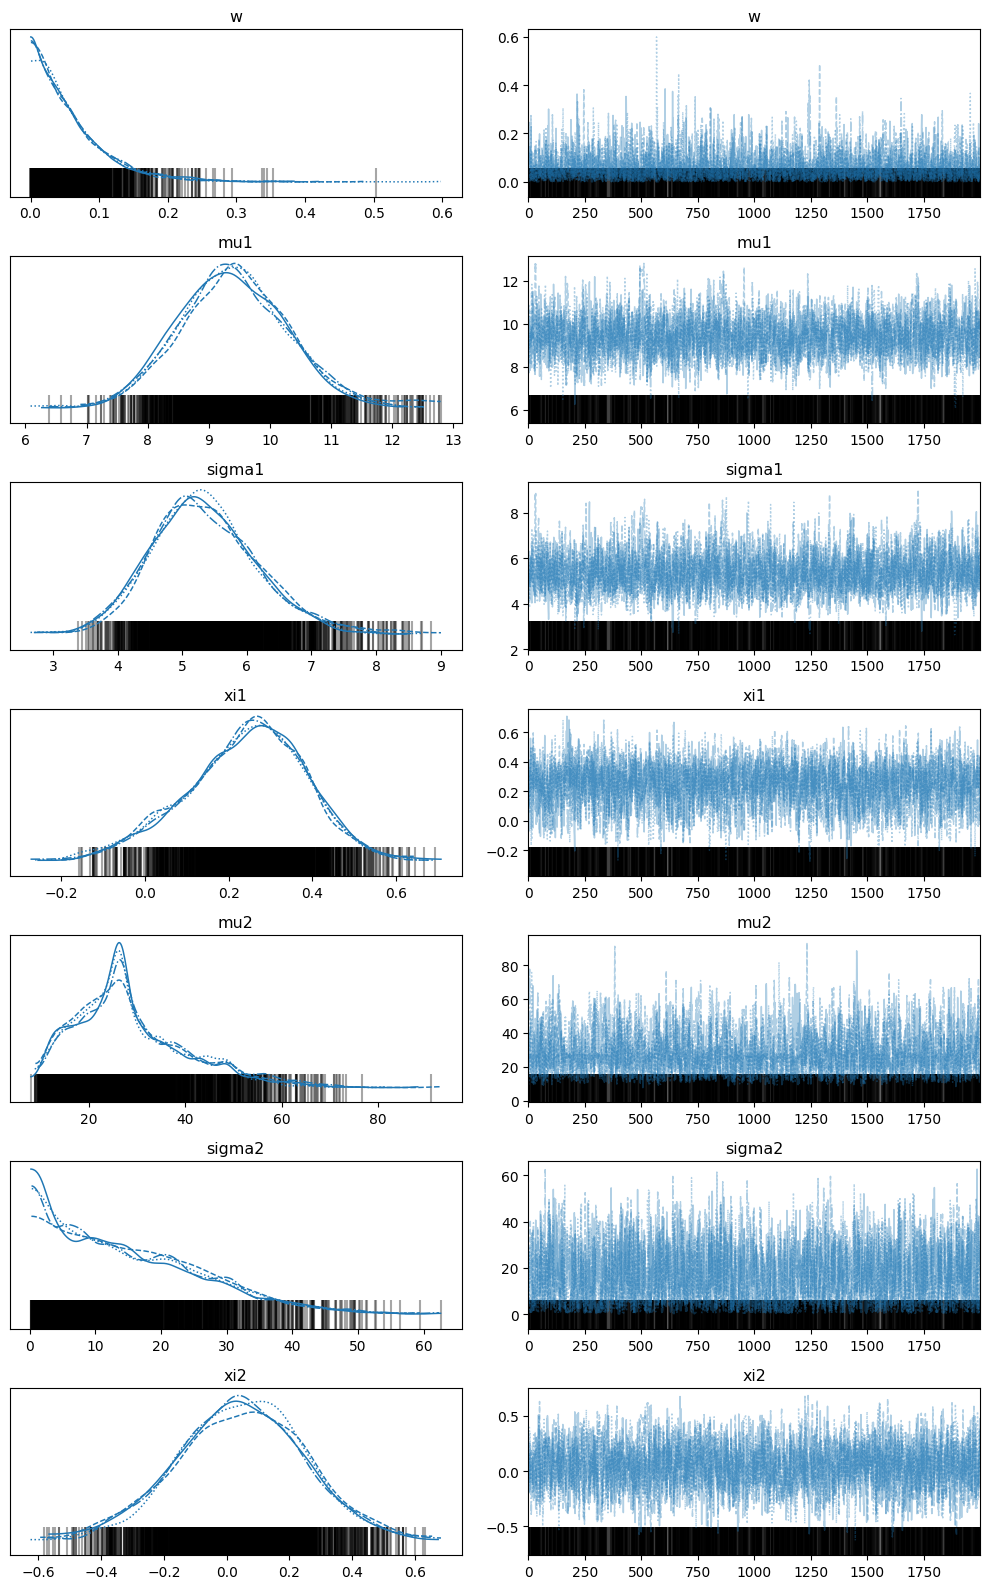

In [4]:
plot_trace(idata_tcev);
plt.show()

## 4. Mixture Flood Frequency Curve

Return levels for the TCEV model cannot be computed analytically — there is no closed-form inverse CDF for a mixture of two GEVs. Instead, for each posterior sample the **mixture CDF** is evaluated on a dense flow grid and the return level is found by numerical inversion:

$$F_\text{mix}(x) = (1-w)\,F_\text{GEV}(x;\,\mu_1,\sigma_1,\xi_1) + w\,F_\text{GEV}(x;\,\mu_2,\sigma_2,\xi_2)$$

The return level $x_T$ satisfies $F_\text{mix}(x_T) = 1 - \text{AEP}/100$.

**The "kink" in the curve**: A characteristic feature of TCEV return level curves is a change in slope — a kink — at the AEP where Component 2 begins to dominate the tail. For this dataset, this typically appears around 1%–0.5% AEP. Below this AEP, the curve may steepen or flatten depending on the shape of Component 2, which is driven almost entirely by the 2021 event.

Compare this curve with Notebooks 1 and 2 — the TCEV upper tail behaviour differs from both GEV and LP3 because it separates the extraordinary component rather than absorbing it into a single set of parameters.

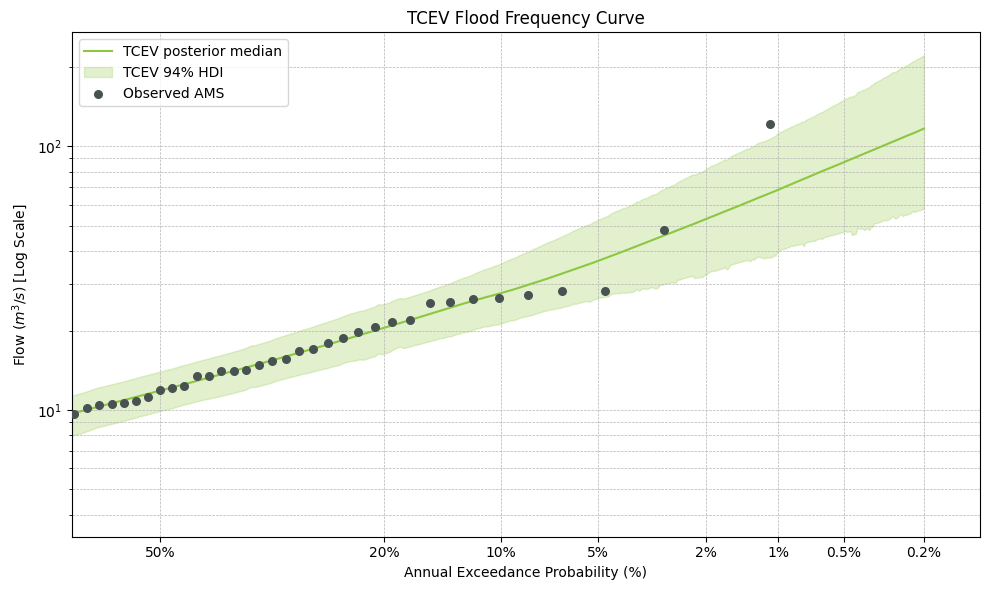

In [5]:
plot_return_levels(idata_tcev, flows);
plt.show()

## 5. Component Separation Plot

This plot answers: *given the fitted model, what is the posterior probability that each year's annual maximum belongs to Component 2 (the extraordinary population)?*

For each year $t$, the probability is computed by applying Bayes' theorem within the mixture:

$$P(\text{Component 2} \mid Q_t) = \frac{w \cdot f_\text{GEV}(Q_t;\;\mu_2,\sigma_2,\xi_2)}{(1-w)\,f_\text{GEV}(Q_t;\;\mu_1,\sigma_1,\xi_1) \;+\; w\,f_\text{GEV}(Q_t;\;\mu_2,\sigma_2,\xi_2)}$$

This is averaged across all posterior samples to give the **posterior mean separation probability** for each year.

**Interpretation**: Most ordinary years should cluster near zero (high confidence of Component 1). The 2021 event should stand out with a noticeably higher Component 2 probability — the key empirical result of the TCEV analysis.

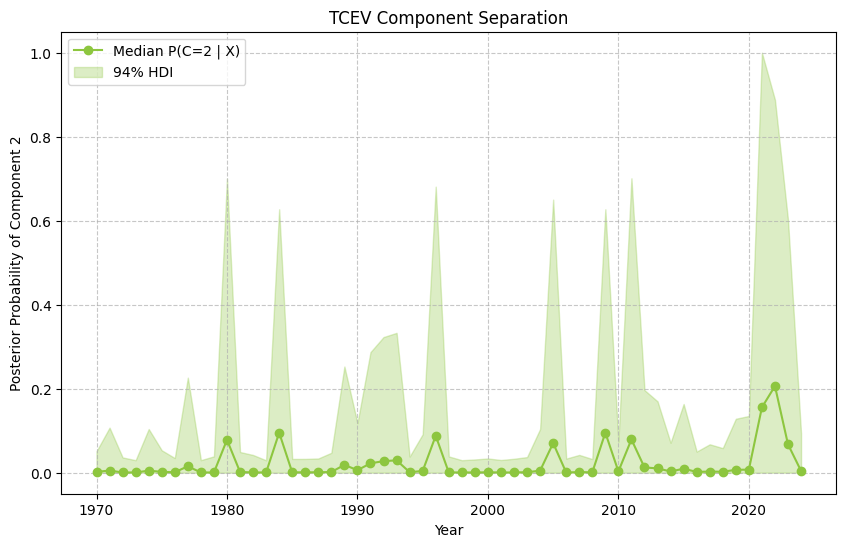

In [6]:
plot_component_separation(idata_tcev, flows);
plt.show()

## 6. Scientific Narrative: What the TCEV Analysis Tells Us

### The 2021 Event

The component separation plot provides **empirical, quantified support** for the mixture model hypothesis. A high posterior probability for 2021 belonging to Component 2 is consistent with the physical argument that the event was generated by a distinct mechanism — an anomalously large or differently structured storm event — rather than the same process that drives the typical annual maximum.

This does not prove causation. What the model says is: *"given the fitted two-population model, the 2021 flow is far more consistent with the extraordinary population than with the ordinary one."* The posterior probability is a measure of that statistical consistency.

### Comparison with Single-Population Models

In Notebook 1, the GEV model responded to 2021 by estimating $\xi \approx 0.31$ — a positive, heavy tail that affects **all** return periods equally, from the 10-year to the 2000-year flood. This is the only mechanism available to a single-population model: stretch the tail to accommodate the outlier.

In the TCEV model, Component 2 absorbs 2021 without inflating the ordinary flood distribution. The consequences are:

- **Frequent events (10%–2% AEP)**: Estimated primarily by Component 1, similar to a GEV fitted *without* the 2021 outlier. TCEV gives lower estimates here than the inflated-$\xi$ GEV.
- **Rare events (0.5% AEP and rarer)**: Increasingly dominated by Component 2. If Component 2 has a heavier tail than Component 1, TCEV may yield *higher* estimates than GEV at very rare return periods — a physically interpretable result.

### Design Implications

The choice between GEV and TCEV matters most for infrastructure designed for rare events — major dams, flood levees protecting critical assets, Probable Maximum Flood estimation. If the record contains an extraordinary event representing a genuinely distinct physical mechanism:

- GEV **overestimates** moderate-return-period flood risk (inflated $\xi$) while potentially **underestimating** the asymptotic upper tail (because the extraordinary component cannot be separated).
- TCEV provides a more defensible physical separation, but at the cost of **substantially wider posterior uncertainty** — 7 parameters fitted to 55 years of data, with Component 2 driven by very few observations.

### Limitations

The TCEV model has known limitations for short records. With a single extraordinary event in 55 years, the Component 2 parameters ($\mu_2,\,\sigma_2,\,\xi_2$) are poorly constrained — the HDI band is correspondingly wide. The posterior uncertainty honestly reflects the genuine difficulty of characterising the behaviour of a rare population from limited data. See Notebook 4 for a direct comparison of the three models' uncertainty at standard design AEPs.